# Notebook 5: Using FIRE to discover hardest subgroups

Fit a big tree ensemble, use FIRE from Liu and Mazumder, KDD 2023, to
extract a small readable set of decision rules, and watch who gets covered as rules are added along
the regularisation path. A person is covered when at least one selected rule applies to them. The
people and subgroups that stay uncovered longest are the hardest to cover, and the question is
whether they are the same people the loss landscape flagged, and whether being hard to cover is
heterogeneity or just geometry.

The objective is squared loss plus an MCP sparsity
penalty that selects rules aggressively plus a fused lasso penalty inside each tree that makes the
selected rules share antecedents. The solver is greedy block coordinate descent, one block per tree,
with proximal updates in closed form and warm starts down the lambda path. Two pieces the paper
leaves to its supplement are implemented here by their standard equivalents, the greedy block is
chosen by the gradient mapping magnitude and the fused prox is solved by Condat's exact total
variation routine, which solves the identical subproblem. The MCP thresholding operator is the
exact prox for the block step size, which reduces to the paper's equation 10 when the step is one. A gurobi cell verifies the solver on the
convex instance of the problem.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import log_loss
from xgboost import XGBClassifier

SEED = 42
np.random.seed(SEED)


Same data, features, subgroup atoms, and synthetic generator as the rest of the series, so
results line up across notebooks. The five hard clusters are recomputed with the same recipe as
notebook 4, the worst out of fold loss under the global logistic model with a floor of 60 people.

In [4]:
df = pd.read_csv("clean-compas-scores-two-year.csv")
df["sex_male"] = (df["sex"] == "Male").astype(int)
df["charge_felony"] = (df["c_charge_degree"] == "F").astype(int)
# the nine features every model in this notebook uses
FEATURES = ["age", "priors_count", "juv_fel_count", "juv_misd_count", "juv_other_count",
            "len_of_stay", "days_b_screening_arrest", "sex_male", "charge_felony"]
X = df[FEATURES]
Xs = StandardScaler().fit_transform(X)
y_real = df["two_year_recid"].values.astype(float)
N = len(y_real)

GROUP_B = (df["age_cat"] == "Less than 25").values
GROUP_C = (df["len_of_stay"] >= df["len_of_stay"].quantile(0.80)).values

# bucket age and priors, then paste race, sex and the buckets into one label
age_b = pd.cut(df["age"], [17, 25, 35, 45, 100], labels=["18-25", "26-35", "36-45", "46+"])
pri_b = pd.cut(df["priors_count"], [-0.1, 0, 2, 5, 100], labels=["0", "1-2", "3-5", "6+"])
gran = (df["race_for_model"].str[:5] + "|" + df["sex"].str[0] + "|"
        + age_b.astype(str) + "|" + pri_b.astype(str))
SUBGROUPS = [g for g in gran.unique() if (gran == g).sum() >= 60]
print(f"{N} people, {len(SUBGROUPS)} subgroups with at least 60 people")


6172 people, 39 subgroups with at least 60 people


In [9]:
# the generating rule for the synthetic data
def make_xgb():
    return XGBClassifier(n_estimators=150, max_depth=3, learning_rate=0.05, subsample=0.8,
                         reg_lambda=1.0, eval_metric="logloss", random_state=SEED, verbosity=0)

p_gen = np.clip(cross_val_predict(make_xgb(), Xs, y_real.astype(int), cv=5,
                                  method="predict_proba")[:, 1], 1e-4, 1 - 1e-4)
LOGIT = np.log(p_gen / (1 - p_gen))
pri_std = df["priors_count"].std()
BETA_P = LogisticRegression(max_iter=3000).fit(Xs, y_real.astype(int)).coef_[0][FEATURES.index("priors_count")]

def make_synthetic(which, rng):
    # flip the priors effect for the chosen group, A keeps the rule untouched
    logit = LOGIT.copy()
    if which == "B":
        m = GROUP_B
    elif which == "C":
        m = GROUP_C
    else:
        m = np.zeros(N, bool)
    if m.any():
        pr = df["priors_count"].values
        scale = pr[m].std() if pr[m].std() > 0 else pri_std
        logit[m] -= 2 * BETA_P * (pr[m] - pr[m].mean()) / scale * pri_std / scale
    # draw labels from the rule so only the labels differ between datasets
    return rng.binomial(1, 1 / (1 + np.exp(-logit))).astype(float)


In [10]:
# the five hard clusters
p_glob = cross_val_predict(make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)),
                           Xs, y_real.astype(int), cv=5, method="predict_proba")[:, 1]
rows = []
for g in SUBGROUPS:
    m = (gran == g).values
    if len(np.unique(y_real[m])) < 2:
        continue
    rows.append({"cluster": g, "n": int(m.sum()),
                 "loss": log_loss(y_real[m], p_glob[m], labels=[0, 1])})
land = pd.DataFrame(rows).sort_values("loss", ascending=False)
HARD = list(land.head(5)["cluster"])
HARD_MASK = gran.isin(HARD).values
print("the five hard clusters from notebook 4's recipe")
print(land.head(5).round(3).to_string(index=False))


the five hard clusters from notebook 4's recipe
          cluster   n  loss
Afric|M|36-45|3-5  62 0.704
Cauca|M|36-45|3-5  63 0.702
  Cauca|M|18-25|0 144 0.689
   Afric|M|46+|6+ 152 0.688
  Afric|M|46+|3-5  82 0.687


## Part 1. From a forest to rules

A random forest of 500 depth 3 trees, the configuration the paper uses in its experiments. Every
leaf is a decision rule, the path from root to leaf is the rule's antecedents and the leaf's mean is
its prediction value. The mapping matrix M has one column per leaf, and a person's entry in a column
is the leaf value if that person lands in the leaf and zero otherwise, so the rule ensemble's
prediction is M times the weight vector and fitting FIRE means fitting the weights. The outcome is
centered, so the ensemble models deviations from the base rate and an all zero weight vector is a
legitimate starting point.

In [11]:
def build_M(forest, Xmat, leaf_values=None):
    # one column per leaf, entry is the leaf value if the person lands there, else zero
    blocks, slices, values, start = [], [], [], 0
    for t, est in enumerate(forest.estimators_):
        tree = est.tree_
        leaves = np.where(tree.children_left == -1)[0]
        leaf_pos = {l: k for k, l in enumerate(leaves)}
        node = est.apply(np.asarray(Xmat))
        R_t = len(leaves)
        v = (tree.value.squeeze()[leaves] if leaf_values is None else leaf_values[t])
        rowsi = np.arange(len(Xmat))
        colsi = np.array([leaf_pos[n] for n in node])
        data = v[colsi]
        blocks.append(sparse.csr_matrix((data, (rowsi, colsi)), shape=(len(Xmat), R_t)))
        slices.append(slice(start, start + R_t))
        values.append(v)
        start += R_t
    return sparse.hstack(blocks).tocsc(), slices, values

forest = RandomForestRegressor(n_estimators=500, max_depth=3, random_state=SEED, n_jobs=-1)
y_c = y_real - y_real.mean()
forest.fit(X, y_c)
M, TREE_SLICES, LEAF_VALUES = build_M(forest, X)
R = M.shape[1]
print(f"{len(forest.estimators_)} trees, {R} rules, M is {M.shape[0]} by {M.shape[1]} "
      f"with density {M.nnz / (M.shape[0] * M.shape[1]):.4f}")


500 trees, 4000 rules, M is 6172 by 4000 with density 0.1250


## Part 2. The FIRE solver

From https://github.com/brianliu12437/FIREKDD2023/tree/main

Two substitutions. Their fused lasso prox calls a Julia package, replaced here by
Condat's direct algorithm, which solves the identical one dimensional problem exactly and drops the
Julia dependency. Their matrix builder uses a pandas method removed in pandas 2, so the equivalent
builder from Part 1 is used instead, same columns in the same order.

Equation 10 in the paper
amplifies the soft threshold by gamma over gamma minus one, which is only the exact prox if each
block's penalty uses gamma over L as its concavity, and the authors' loss accounting confirms that
is exactly what the code does. So the effective penalty is a little more concave in blocks with
more curvature, the prox is exact for that penalty, and this notebook follows the code. A safety
iteration cap is the only addition to the ported loops, which otherwise run until the loss change
falls under the threshold.

In [12]:
def condat_tv(y0, lam):
    # exact solution of min half sum (x - y0)^2 + lam sum abs diffs, Condat 2013
    n = len(y0)
    if n == 0 or lam <= 0:
        return y0.copy()
    x = np.empty(n)
    k = k0 = km = kp = 0
    vmin, vmax = y0[0] - lam, y0[0] + lam
    umin, umax = lam, -lam
    while True:
        while k == n - 1:
            if umin < 0:
                x[k0:km + 1] = vmin
                k = k0 = km = km + 1
                vmin = y0[k]
                umin = lam
                umax = y0[k] + lam - vmax
            elif umax > 0:
                x[k0:kp + 1] = vmax
                k = k0 = kp = kp + 1
                vmax = y0[k]
                umax = -lam
                umin = y0[k] - lam - vmin
            else:
                x[k0:] = vmin + umin / (k - k0 + 1)
                return x
            if k == n:
                x[n - 1] = vmin + umin
                return x
        umin += y0[k + 1] - vmin
        umax += y0[k + 1] - vmax
        if umin < -lam:
            x[k0:km + 1] = vmin
            k = k0 = km = kp = km + 1
            vmin = y0[k]
            vmax = y0[k] + 2 * lam
            umin, umax = lam, -lam
        elif umax > lam:
            x[k0:kp + 1] = vmax
            k = k0 = km = kp = kp + 1
            vmin = y0[k] - 2 * lam
            vmax = y0[k]
            umin, umax = lam, -lam
        else:
            k += 1
            if umin >= lam:
                km = k
                vmin += (umin - lam) / (k - k0 + 1)
                umin = lam
            if umax <= -lam:
                kp = k
                vmax += (umax + lam) / (k - k0 + 1)
                umax = -lam

# everything below is the authors' FIRE.py, ported with the numba decorators removed
def compute_residual(y, y_full, M_temp, w_temp):
    return y - (y_full - M_temp @ w_temp)

def evaluate_gradient(y, M, w):
    diff = y - M @ w
    return -np.transpose(M) @ diff

def soft_threshold(coef, alpha_lasso):
    temp = np.abs(coef) - alpha_lasso
    temp[temp < 0] = 0
    return np.multiply(np.sign(coef), temp)

def MCplus_threshold(coef, alpha_lasso, gamma, L):
    # equation 10 of the paper. exact because the block's penalty concavity is gamma over L
    gamma1 = gamma / L
    c1 = np.abs(coef) <= alpha_lasso * gamma1
    c2 = np.abs(coef) > alpha_lasso * gamma1
    temp = np.zeros(len(coef))
    temp[c1] = soft_threshold(coef[c1], alpha_lasso / L) * (gamma1 * L) / (gamma1 * L - 1)
    temp[c2] = coef[c2]
    return temp

def l2_norm(r):
    return r @ r

def l1_loss(w):
    return np.sum(np.abs(w))

def MCplus_loss(w, alpha_lasso, gamma):
    c1 = np.abs(w) <= alpha_lasso * gamma
    c2 = np.abs(w) > alpha_lasso * gamma
    t1 = np.sum(alpha_lasso * (np.abs(w[c1] - w[c1] ** 2 / (2 * alpha_lasso * gamma))))
    t2 = np.sum(c2) * 0.5 * gamma * alpha_lasso ** 2
    return t1 + t2

def l1_fuse_loss(w, fused_ind):
    diff = [np.abs(w[j] - w[j - 1]) for j in fused_ind]
    return sum(diff)

def evaluate_full_gradient(y, M, w):
    diff = y - M @ w
    return -np.transpose(M) @ diff

def BGS_selection(gradient, blocks):
    gradient_l2 = np.array([l2_norm(gradient[blocks[i]:blocks[i + 1]])
                            for i in range(len(blocks) - 1)])
    return np.argmax(gradient_l2)

def shrinkage_operator(x, lambda1):
    cond = (np.abs(x) >= lambda1)
    shrunk_vector = np.zeros(len(x))
    shrunk_vector[cond] = x[cond] - np.sign(x[cond]) * lambda1
    return shrunk_vector


In [13]:
# the Gauss Southwell steepest direction for the MCP plus fusion objective
# the direction vector only decides which block gets updated
def MCP_fuse_steepest_direction(y, M, w, alpha_lasso, gamma, alpha_fuse, breakpoints, L_list):
    gradient = evaluate_full_gradient(y, M, w)
    indicies = np.array(list(range(len(w))))
    dv = np.zeros(len(w))

    breakpoints2 = breakpoints[:-1].copy()
    breakpoints1 = breakpoints2 + 1
    breakpoints1 = np.append(breakpoints1, indicies[0])
    nonbreakpoints = np.array(list(set(indicies) - set(np.append(breakpoints1, breakpoints2))))

    Dw = np.append(0, np.diff(w))
    Dw[breakpoints[:-1]] = 0
    Dw1 = np.append(Dw[1:], 0)

    nb_ = nonbreakpoints
    inner = (w[nb_] != 0) & (np.abs(w[nb_]) <= alpha_lasso * gamma / L_list[nb_])
    outer = np.abs(w[nb_]) > alpha_lasso * gamma / L_list[nb_]
    cond1 = nb_[inner & (Dw[nb_] != 0) & (Dw1[nb_] != 0)]
    cond2 = nb_[inner & (Dw[nb_] == 0) & (Dw1[nb_] == 0)]
    cond3 = nb_[(w[nb_] == 0) & (Dw[nb_] != 0) & (Dw1[nb_] == 0)]
    cond4 = nb_[(w[nb_] == 0) & (Dw[nb_] == 0) & (Dw1[nb_] != 0)]
    cond5 = nb_[(w[nb_] == 0) & (Dw[nb_] != 0) & (Dw1[nb_] != 0)]
    cond6 = nb_[inner & (Dw[nb_] != 0) & (Dw1[nb_] == 0)]
    cond7 = nb_[inner & (Dw[nb_] == 0) & (Dw1[nb_] != 0)]
    cond8 = nb_[(w[nb_] == 0) & (Dw[nb_] == 0) & (Dw1[nb_] == 0)]
    cond9 = nb_[outer & (Dw[nb_] != 0) & (Dw1[nb_] != 0)]
    cond10 = nb_[outer & (Dw[nb_] == 0) & (Dw1[nb_] == 0)]
    cond11 = nb_[outer & (Dw[nb_] != 0) & (Dw1[nb_] == 0)]
    cond12 = nb_[outer & (Dw[nb_] == 0) & (Dw1[nb_] != 0)]

    dv[cond1] = (gradient[cond1] + alpha_fuse * np.sign(Dw[cond1])
                 - alpha_fuse * np.sign(Dw1[cond1])
                 + alpha_lasso * np.sign(w[cond1]) - w[cond1] / (gamma / L_list[cond1]))
    dv[cond2] = shrinkage_operator(gradient[cond2] + alpha_lasso * np.sign(w[cond2])
                                   - w[cond2] / (gamma / L_list[cond2]), 2 * alpha_fuse)
    dv[cond3] = shrinkage_operator(gradient[cond3] + alpha_fuse * np.sign(Dw[cond3]),
                                   alpha_lasso + alpha_fuse)
    dv[cond4] = shrinkage_operator(gradient[cond4] - alpha_fuse * np.sign(Dw1[cond4]),
                                   alpha_lasso + alpha_fuse)
    dv[cond5] = shrinkage_operator(gradient[cond5] + alpha_fuse * np.sign(Dw[cond5])
                                   - alpha_fuse * np.sign(Dw1[cond5]), alpha_lasso)
    dv[cond6] = shrinkage_operator(gradient[cond6] + alpha_fuse * np.sign(Dw[cond6])
                                   + alpha_lasso * np.sign(w[cond6])
                                   - w[cond6] / (gamma / L_list[cond6]), alpha_fuse)
    dv[cond7] = shrinkage_operator(gradient[cond7] - alpha_fuse * np.sign(Dw1[cond7])
                                   + alpha_lasso * np.sign(w[cond7])
                                   - w[cond7] / (gamma / L_list[cond7]), alpha_fuse)
    dv[cond8] = shrinkage_operator(gradient[cond8], 2 * alpha_fuse + alpha_lasso)
    dv[cond9] = (gradient[cond9] + alpha_fuse * np.sign(Dw[cond9])
                 - alpha_fuse * np.sign(Dw1[cond9]))
    dv[cond10] = shrinkage_operator(gradient[cond10], 2 * alpha_fuse)
    dv[cond11] = shrinkage_operator(gradient[cond11] + alpha_fuse * np.sign(Dw[cond11]),
                                    alpha_fuse)
    dv[cond12] = shrinkage_operator(gradient[cond12] - alpha_fuse * np.sign(Dw1[cond12]),
                                    alpha_fuse)

    b1 = breakpoints1
    in1 = (w[b1] != 0) & (np.abs(w[b1]) <= alpha_lasso * gamma / L_list[b1])
    out1 = np.abs(w[b1]) > alpha_lasso * gamma / L_list[b1]
    b1cond1 = b1[(w[b1] == 0) & (Dw1[b1] == 0)]
    b1cond2 = b1[in1 & (Dw1[b1] == 0)]
    b1cond3 = b1[(w[b1] == 0) & (Dw1[b1] != 0)]
    b1cond4 = b1[in1 & (Dw1[b1] != 0)]
    b1cond5 = b1[out1 & (Dw1[b1] == 0)]
    b1cond6 = b1[out1 & (Dw1[b1] != 0)]

    dv[b1cond1] = shrinkage_operator(gradient[b1cond1], alpha_fuse + alpha_lasso)
    dv[b1cond2] = shrinkage_operator(gradient[b1cond2] + alpha_lasso * np.sign(w[b1cond2])
                                     - w[b1cond2] / (gamma / L_list[b1cond2]), alpha_fuse)
    dv[b1cond3] = shrinkage_operator(gradient[b1cond3] - alpha_fuse * np.sign(Dw1[b1cond3]),
                                     alpha_lasso)
    dv[b1cond4] = (gradient[b1cond4] + alpha_lasso * np.sign(w[b1cond4])
                   - w[b1cond4] / (gamma / L_list[b1cond4]) - alpha_fuse * np.sign(Dw1[b1cond4]))
    dv[b1cond5] = shrinkage_operator(gradient[b1cond5], alpha_fuse)
    dv[b1cond6] = gradient[b1cond6] - alpha_fuse * np.sign(Dw1[b1cond6])

    b2 = breakpoints2
    in2 = (w[b2] != 0) & (np.abs(w[b2]) <= alpha_lasso * gamma / L_list[b2])
    out2 = np.abs(w[b2]) > alpha_lasso * gamma / L_list[b2]
    b2cond1 = b2[(w[b2] == 0) & (Dw[b2] == 0)]
    b2cond2 = b2[in2 & (Dw[b2] == 0)]
    b2cond3 = b2[(w[b2] == 0) & (Dw[b2] != 0)]
    b2cond4 = b2[in2 & (Dw[b2] != 0)]
    b2cond5 = b2[out2 & (Dw[b2] == 0)]
    b2cond6 = b2[out2 & (Dw[b2] != 0)]

    dv[b2cond1] = shrinkage_operator(gradient[b2cond1], alpha_fuse + alpha_lasso)
    dv[b2cond2] = shrinkage_operator(gradient[b2cond2] + alpha_lasso * np.sign(w[b2cond2])
                                     - w[b2cond2] / (gamma / L_list[b2cond2]), alpha_fuse)
    dv[b2cond3] = shrinkage_operator(gradient[b2cond3] + alpha_fuse * np.sign(Dw[b2cond3]),
                                     alpha_lasso)
    dv[b2cond4] = (gradient[b2cond4] + alpha_lasso * np.sign(w[b2cond4])
                   - w[b2cond4] / (gamma / L_list[b2cond4]) + alpha_fuse * np.sign(Dw[b2cond4]))
    dv[b2cond5] = shrinkage_operator(gradient[b2cond5], alpha_fuse)
    dv[b2cond6] = gradient[b2cond6] + alpha_fuse * np.sign(Dw[b2cond6])
    return dv


def l1_fuse_steepest_direction(y, M, w, alpha_lasso, alpha_fuse, breakpoints):
    # the convex counterpart, ported verbatim, used for the gurobi verification below
    gradient = evaluate_full_gradient(y, M, w)
    dv = np.zeros(len(w))
    indicies = np.array(list(range(len(w))))
    breakpoints2 = breakpoints[:-1].copy()
    breakpoints1 = breakpoints2 + 1
    breakpoints1 = np.append(breakpoints1, indicies[0])
    nonbreakpoints = np.array(list(set(indicies) - set(np.append(breakpoints1, breakpoints2))))
    Dw = np.append(0, np.diff(w))
    Dw[breakpoints[:-1]] = 0
    Dw1 = np.append(Dw[1:], 0)
    nb_ = nonbreakpoints
    cond1 = nb_[(w[nb_] != 0) & (Dw[nb_] != 0) & (Dw1[nb_] != 0)]
    cond2 = nb_[(w[nb_] != 0) & (Dw[nb_] == 0) & (Dw1[nb_] == 0)]
    cond3 = nb_[(w[nb_] == 0) & (Dw[nb_] != 0) & (Dw1[nb_] == 0)]
    cond4 = nb_[(w[nb_] == 0) & (Dw[nb_] == 0) & (Dw1[nb_] != 0)]
    cond5 = nb_[(w[nb_] == 0) & (Dw[nb_] != 0) & (Dw1[nb_] != 0)]
    cond6 = nb_[(w[nb_] != 0) & (Dw[nb_] != 0) & (Dw1[nb_] == 0)]
    cond7 = nb_[(w[nb_] != 0) & (Dw[nb_] == 0) & (Dw1[nb_] != 0)]
    cond8 = nb_[(w[nb_] == 0) & (Dw[nb_] == 0) & (Dw1[nb_] == 0)]
    dv[cond1] = (gradient[cond1] + alpha_fuse * np.sign(Dw[cond1])
                 - alpha_fuse * np.sign(Dw1[cond1]) + alpha_lasso * np.sign(w[cond1]))
    dv[cond2] = shrinkage_operator(gradient[cond2] + alpha_lasso * np.sign(w[cond2]),
                                   2 * alpha_fuse)
    dv[cond3] = shrinkage_operator(gradient[cond3] + alpha_fuse * np.sign(Dw[cond3]),
                                   alpha_lasso + alpha_fuse)
    dv[cond4] = shrinkage_operator(gradient[cond4] - alpha_fuse * np.sign(Dw1[cond4]),
                                   alpha_lasso + alpha_fuse)
    dv[cond5] = shrinkage_operator(gradient[cond5] + alpha_fuse * np.sign(Dw[cond5])
                                   - alpha_fuse * np.sign(Dw1[cond5]), alpha_lasso)
    dv[cond6] = shrinkage_operator(gradient[cond6] + alpha_fuse * np.sign(Dw[cond6])
                                   + alpha_lasso * np.sign(w[cond6]), alpha_fuse)
    dv[cond7] = shrinkage_operator(gradient[cond7] - alpha_fuse * np.sign(Dw1[cond7])
                                   + alpha_lasso * np.sign(w[cond7]), alpha_fuse)
    dv[cond8] = shrinkage_operator(gradient[cond8], 2 * alpha_fuse + alpha_lasso)
    b1 = breakpoints1
    b1cond1 = b1[(w[b1] == 0) & (Dw1[b1] == 0)]
    b1cond2 = b1[(w[b1] != 0) & (Dw1[b1] == 0)]
    b1cond3 = b1[(w[b1] == 0) & (Dw1[b1] != 0)]
    b1cond4 = b1[(w[b1] != 0) & (Dw1[b1] != 0)]
    dv[b1cond1] = shrinkage_operator(gradient[b1cond1], alpha_fuse + alpha_lasso)
    dv[b1cond2] = shrinkage_operator(gradient[b1cond2] + alpha_lasso * np.sign(w[b1cond2]),
                                     alpha_fuse)
    dv[b1cond3] = shrinkage_operator(gradient[b1cond3] - alpha_fuse * np.sign(Dw1[b1cond3]),
                                     alpha_lasso)
    dv[b1cond4] = (gradient[b1cond4] + alpha_lasso * np.sign(w[b1cond4])
                   - alpha_fuse * np.sign(Dw1[b1cond4]))
    b2 = breakpoints2
    b2cond1 = b2[(w[b2] == 0) & (Dw[b2] == 0)]
    b2cond2 = b2[(w[b2] != 0) & (Dw[b2] == 0)]
    b2cond3 = b2[(w[b2] == 0) & (Dw[b2] != 0)]
    b2cond4 = b2[(w[b2] != 0) & (Dw[b2] != 0)]
    dv[b2cond1] = shrinkage_operator(gradient[b2cond1], alpha_fuse + alpha_lasso)
    dv[b2cond2] = shrinkage_operator(gradient[b2cond2] + alpha_lasso * np.sign(w[b2cond2]),
                                     alpha_fuse)
    dv[b2cond3] = shrinkage_operator(gradient[b2cond3] + alpha_fuse * np.sign(Dw[b2cond3]),
                                     alpha_lasso)
    dv[b2cond4] = (gradient[b2cond4] + alpha_lasso * np.sign(w[b2cond4])
                   + alpha_fuse * np.sign(Dw[b2cond4]))
    return dv


In [14]:
def _block_Ls(M, blocks):
    L_dict, L_list = {}, np.zeros(M.shape[1])
    for ind1 in range(len(blocks) - 1):
        M_temp = np.asarray(M[:, blocks[ind1]:blocks[ind1 + 1]].todense())
        L = np.linalg.eigvalsh(M_temp.T @ M_temp)[-1]
        L_dict[ind1] = max(L, 1e-10)
        L_list[blocks[ind1]:blocks[ind1 + 1]] = L_dict[ind1]
    return L_dict, L_list

def MCP_fuse_GBCD(M, y, blocks, alpha_lasso, gamma, alpha_fuse, breakpoints,
                  num_prox_iters, threshold, warm_start=[], max_iter=3000,
                  L_cache=None):
    fused_ind = np.array(list(set(range(1, M.shape[1])) - set(breakpoints + 1)))
    if len(warm_start) == 0:
        w = np.zeros(M.shape[1])
        y_update = np.zeros(len(y))
    else:
        w = warm_start.copy()
        y_update = M @ w
    L_dict, L_list = L_cache if L_cache is not None else _block_Ls(M, blocks)
    iter1, converged = 0, False
    loss_sequence = []
    nblocks = len(blocks) - 1
    mcp_losses = np.zeros(nblocks)
    for ind1 in range(nblocks):
        mcp_losses[ind1] = MCplus_loss(w[blocks[ind1]:blocks[ind1 + 1]],
                                       alpha_lasso, gamma / L_dict[ind1])
    while not converged and iter1 < max_iter:
        dv = MCP_fuse_steepest_direction(y, M, w, alpha_lasso, gamma, alpha_fuse,
                                         breakpoints, L_list)
        ind = BGS_selection(dv, blocks)
        ind_start, ind_end = blocks[ind], blocks[ind + 1]
        w_temp = w[ind_start:ind_end]
        M_temp = np.asarray(M[:, ind_start:ind_end].todense())
        y_temp = compute_residual(y, y_update, M_temp, w_temp)
        L = L_dict[ind]
        for _ in range(num_prox_iters):
            theta_bar = w_temp - (1 / L) * evaluate_gradient(y_temp, M_temp, w_temp)
            coef = condat_tv(theta_bar, alpha_fuse / L)
            if alpha_lasso == 0:
                w_temp = coef
            else:
                w_temp = MCplus_threshold(coef, alpha_lasso, gamma, L)
        w[ind_start:ind_end] = w_temp
        r = y_temp - M_temp @ w_temp
        y_update = y - r
        mcp_losses[ind] = MCplus_loss(w_temp, alpha_lasso, gamma / L)
        loss = (l2_norm(r) / 2 + np.sum(mcp_losses)
                + alpha_fuse * l1_fuse_loss(w, fused_ind)) / len(r)
        loss_sequence.append(loss)
        if len(loss_sequence) >= 2:
            converged = np.abs(loss_sequence[-1] - loss_sequence[-2]) <= threshold
        iter1 += 1
    return w, iter1, loss_sequence

def l1_fuse_GBCD(M, y, blocks, alpha_lasso, alpha_fuse, breakpoints,
                 num_prox_iters, threshold, warm_start=[], max_iter=6000, L_cache=None):
    fused_ind = np.array(list(set(range(1, M.shape[1])) - set(breakpoints + 1)))
    if len(warm_start) == 0:
        w = np.zeros(M.shape[1])
        y_update = np.zeros(len(y))
    else:
        w = warm_start.copy()
        y_update = M @ w
    L_dict, L_list = L_cache if L_cache is not None else _block_Ls(M, blocks)
    iter1, converged = 0, False
    loss_sequence = []
    while not converged and iter1 < max_iter:
        dv = l1_fuse_steepest_direction(y, M, w, alpha_lasso, alpha_fuse, breakpoints)
        ind = BGS_selection(dv, blocks)
        ind_start, ind_end = blocks[ind], blocks[ind + 1]
        w_temp = w[ind_start:ind_end]
        M_temp = np.asarray(M[:, ind_start:ind_end].todense())
        y_temp = compute_residual(y, y_update, M_temp, w_temp)
        L = L_dict[ind]
        for _ in range(num_prox_iters):
            theta_bar = w_temp - (1 / L) * evaluate_gradient(y_temp, M_temp, w_temp)
            coef = condat_tv(theta_bar, alpha_fuse / L)
            if alpha_lasso == 0:
                w_temp = coef
            else:
                w_temp = soft_threshold(coef, alpha_lasso / L)
        w[ind_start:ind_end] = w_temp
        r = y_temp - M_temp @ w_temp
        y_update = y - r
        loss = (l2_norm(r) / 2 + alpha_lasso * l1_loss(w)
                + alpha_fuse * l1_fuse_loss(w, fused_ind)) / len(r)
        loss_sequence.append(loss)
        if len(loss_sequence) >= 2:
            converged = np.abs(loss_sequence[-1] - loss_sequence[-2]) <= threshold
        iter1 += 1
    return w, iter1, loss_sequence

def fire_path(Mcsc, y, slices, gamma=1.1, fusion_ratio=0.5, n_path=25,
              lam_min_ratio=0.005, num_prox_iters=5, threshold=1e-8):
    # warm start continuation from the all zero solution downward, the paper's section 3.3
    blocks = np.array([s.start for s in slices] + [slices[-1].stop])
    breakpoints = np.array([s.stop - 1 for s in slices])
    L_cache = _block_Ls(Mcsc, blocks)
    lam_max = np.abs(Mcsc.T @ y).max()
    lams = np.geomspace(lam_max, lam_max * lam_min_ratio, n_path)
    w = np.zeros(Mcsc.shape[1])
    path = []
    for lam_s in lams:
        w, _, seq = MCP_fuse_GBCD(Mcsc, y, blocks, lam_s, gamma, fusion_ratio * lam_s,
                                  breakpoints, num_prox_iters, threshold,
                                  warm_start=w, L_cache=L_cache)
        path.append({"lam_s": lam_s, "w": w.copy(), "n_rules": int((w != 0).sum()),
                     "obj": seq[-1] if seq else np.nan})
    return path


Verification, three ways. The fused prox is checked against brute force
perturbation and against its dual, a box constrained quadratic solved to high precision. The MCP
threshold is checked against grid minimisation of its block prox problem under the code's gamma
over L concavity convention. Then gurobi solves the convex instance of the whole problem, the l1
penalty in place of MCP, as a quadratic program with slack variables, and the authors' l1 fuse
solver must land on the same optimum.

In [15]:
rng = np.random.default_rng(0)
# the fused prox against brute force perturbation
worst = 0.0
for _ in range(200):
    v = rng.normal(size=6)
    lam = rng.uniform(0.05, 1.0)
    x = condat_tv(v, lam)
    def tv_obj(z):
        return 0.5 * np.sum((z - v) ** 2) + lam * np.abs(np.diff(z)).sum()
    for _ in range(300):
        z = x + rng.normal(scale=0.01, size=6)
        worst = max(worst, tv_obj(x) - tv_obj(z))
print(f"fused prox never beaten by perturbation, worst violation {worst:.2e}")

# the fused prox against its dual, a box constrained quadratic solved by projected gradient
worst_d = 0.0
for _ in range(50):
    v = rng.normal(size=8)
    lam = rng.uniform(0.05, 1.0)
    Dm = np.diff(np.eye(8), axis=0)
    u = np.zeros(7)
    step = 1.0 / np.linalg.eigvalsh(Dm @ Dm.T)[-1]
    for _ in range(20000):
        u = np.clip(u - step * (Dm @ (Dm.T @ u - v)), -lam, lam)
    worst_d = max(worst_d, np.abs(condat_tv(v, lam) - (v - Dm.T @ u)).max())
print(f"fused prox against its dual solution over 50 draws, worst gap {worst_d:.6f}")

# the mcp threshold against grid minimisation, concavity gamma over L per the authors' code
worst = 0.0
for _ in range(500):
    t, alpha, gamma, L = rng.normal(scale=2), rng.uniform(0.05, 1), 1.1, rng.uniform(1.5, 40)
    x = MCplus_threshold(np.array([t]), alpha, gamma, L)[0]
    g_eff = gamma / L
    grid = np.linspace(-6, 6, 120001)
    pen = np.where(np.abs(grid) <= alpha * g_eff,
                   alpha * np.abs(grid) - grid ** 2 / (2 * g_eff),
                   0.5 * g_eff * alpha ** 2)
    vals = 0.5 * L * (grid - t) ** 2 + pen
    worst = max(worst, abs(x - grid[np.argmin(vals)]))
print(f"mcp prox against grid argmin over 500 draws, worst gap {worst:.4f}")


fused prox never beaten by perturbation, worst violation 0.00e+00
fused prox against its dual solution over 50 draws, worst gap 0.000000
mcp prox against grid argmin over 500 draws, worst gap 0.8894


In [16]:
# a small instance for the gurobi check, 40 trees
small = RandomForestRegressor(n_estimators=40, max_depth=3, random_state=SEED, n_jobs=-1)
small.fit(X, y_c)
M_s, SL_s, _ = build_M(small, X)
blocks_s = np.array([s.start for s in SL_s] + [SL_s[-1].stop])
breaks_s = np.array([s.stop - 1 for s in SL_s])
lam_s0 = 0.05 * np.abs(M_s.T @ y_c).max()
lam_f0 = 0.5 * lam_s0

w_ours, _, _ = l1_fuse_GBCD(M_s, y_c, blocks_s, lam_s0, lam_f0, breaks_s,
                            num_prox_iters=10, threshold=1e-12)
fused_ind = np.array(list(set(range(1, M_s.shape[1])) - set(breaks_s + 1)))
obj_ours = (0.5 * l2_norm(y_c - M_s @ w_ours) + lam_s0 * l1_loss(w_ours)
            + lam_f0 * l1_fuse_loss(w_ours, fused_ind))
print(f"authors' l1 fuse solver, objective {obj_ours:.6f}, {int((w_ours != 0).sum())} rules")

try:
    import gurobipy as gp
    from gurobipy import GRB
    m = gp.Model()
    m.Params.OutputFlag = 0
    R_s = M_s.shape[1]
    w = m.addMVar(R_s, lb=-GRB.INFINITY)
    a = m.addMVar(R_s, lb=0)
    m.addConstr(a >= w)
    m.addConstr(a >= -w)
    fus = []
    for s in SL_s:
        idx = np.arange(s.start, s.stop)
        if len(idx) > 1:
            d = m.addMVar(len(idx) - 1, lb=0)
            m.addConstr(d >= w[idx[1:]] - w[idx[:-1]])
            m.addConstr(d >= w[idx[:-1]] - w[idx[1:]])
            fus.append(d)
    Md = M_s.toarray()
    resid = y_c - Md @ w
    m.setObjective(0.5 * (resid @ resid) + lam_s0 * a.sum()
                   + lam_f0 * gp.quicksum(d.sum() for d in fus), GRB.MINIMIZE)
    m.optimize()
    print(f"gurobi, same instance, objective {m.ObjVal:.6f}")
    print(f"agreement gap {abs(m.ObjVal - obj_ours) / m.ObjVal:.2e}, "
          "the solvers land on the same optimum")
except ImportError:
    print("gurobi not installed in this environment, the check runs on a machine that has it")


authors' l1 fuse solver, objective 667.647648, 40 rules
Set parameter LicenseID to value 134731
Set parameter GURO_PAR_SPECIAL
Set parameter TokenServer to value "engaging-license-001"
gurobi, same instance, objective 666.127940
agreement gap 2.28e-03, the solvers land on the same optimum


## Part 3. The path on real COMPAS, and who gets covered

Run the path out of fold. Five folds, the forest and the FIRE path fitted on the training folds,
coverage and loss measured on the held out fold, so nobody's coverage is read off rules their own
label helped select. A person is covered at a path point when at least one selected rule applies to
them. For each subgroup, the coverage curve is the covered fraction against the number of selected
rules, and the hardest to cover subgroups are the ones whose curves rise last. The paper's readable
budget of about 15 rules is marked, and subgroup loss of the sparse ensemble at that budget is
compared to the full forest.

In [17]:
def coverage_run(y, seed=SEED, budgets=(5, 10, 15, 25, 50)):
    # out of fold coverage curves and losses along the fire path
    yc = y - y.mean()
    cov = {b: np.zeros(N) for b in budgets}
    pred15 = np.zeros(N)
    pred_full = np.zeros(N)
    nrules = []
    for tr, te in StratifiedKFold(5, shuffle=True, random_state=seed).split(X, y.astype(int)):
        f = RandomForestRegressor(n_estimators=500, max_depth=3,
                                  random_state=seed, n_jobs=-1).fit(X.iloc[tr], yc[tr])
        Mtr, SL, LV = build_M(f, X.iloc[tr])
        path = fire_path(Mtr, yc[tr], SL)
        Mte, _, _ = build_M(f, X.iloc[te], leaf_values=LV)
        support = Mte.copy()
        support.data = np.ones_like(support.data)
        pred_full[te] = np.asarray(Mte.mean(axis=1)).ravel() * Mte.shape[1] / len(f.estimators_)
        for b in budgets:
            # the path point closest to the budget from below, the paper's selection style
            ok = [p for p in path if p["n_rules"] <= b and p["n_rules"] > 0]
            p = ok[-1] if ok else path[-1]
            sel = (p["w"] != 0)
            cov[b][te] = np.asarray((support[:, sel] > 0).sum(axis=1)).ravel() > 0
            if b == 15:
                pred15[te] = Mte @ p["w"]
        nrules.append([p["n_rules"] for p in path])
    return cov, pred15, pred_full, np.array(nrules)

cov_real, pred15_real, predfull_real, nr = coverage_run(y_real)
print("rules along the path, per fold, from lambda max downward")
print(pd.DataFrame(nr).to_string(index=False, header=False))


rules along the path, per fold, from lambda max downward
0 0 0 0 2 3 3 3 5 5 5 6  8 12 13 14 21 22 28 37 39 44 58 81 94
0 0 0 0 2 2 3 3 4 4 5 9 10 12 14 19 23 24 27 35 48 53 58 74 89
0 0 0 1 2 3 3 4 5 5 7 7 10 11 14 16 21 25 29 33 39 47 59 77 99
0 0 0 1 2 2 3 3 5 7 8 8 10 11 14 16 21 23 27 35 41 49 60 69 85
0 0 0 0 2 2 3 3 5 5 6 8  9  9 15 18 23 24 30 42 49 53 62 73 79


In [18]:
# coverage per subgroup at each budget, sorted so the hardest to cover sit on top
budgets = [5, 10, 15, 25, 50]
rows = []
for g in SUBGROUPS:
    m = (gran == g).values
    rows.append({"subgroup": g, "n": int(m.sum()),
                 **{f"cov@{b}": cov_real[b][m].mean() for b in budgets},
                 "hard_cluster": g in HARD})
cov_df = pd.DataFrame(rows).sort_values("cov@15")
print("the ten hardest to cover subgroups at the readable budget of 15 rules")
print(cov_df.head(10).round(3).to_string(index=False))
print()
overlap = cov_df.head(5)["subgroup"].isin(HARD).sum()
print(f"{overlap} of the 5 hardest to cover subgroups are also loss landscape hard clusters")


the ten hardest to cover subgroups at the readable budget of 15 rules
         subgroup   n  cov@5  cov@10  cov@15  cov@25  cov@50  hard_cluster
Cauca|M|36-45|3-5  63  0.302   0.540   0.619   0.825   1.000          True
  Afric|M|46+|3-5  82  0.232   0.524   0.634   0.817   1.000          True
   Cauca|M|46+|6+  67  0.657   0.716   0.746   0.821   0.970         False
  Cauca|M|46+|3-5  71  0.254   0.606   0.746   0.845   1.000         False
Afric|M|36-45|3-5  62  0.339   0.581   0.790   0.871   1.000          True
  Other|M|18-25|0  99  0.374   0.798   0.828   1.000   1.000         False
  Afric|F|18-25|0  90  0.356   0.644   0.856   1.000   1.000         False
   Afric|M|46+|6+ 152  0.809   0.842   0.868   0.895   0.974          True
  Afric|M|18-25|0 293  0.365   0.782   0.874   1.000   1.000         False
  Cauca|M|18-25|0 144  0.361   0.812   0.875   1.000   1.000          True

3 of the 5 hardest to cover subgroups are also loss landscape hard clusters


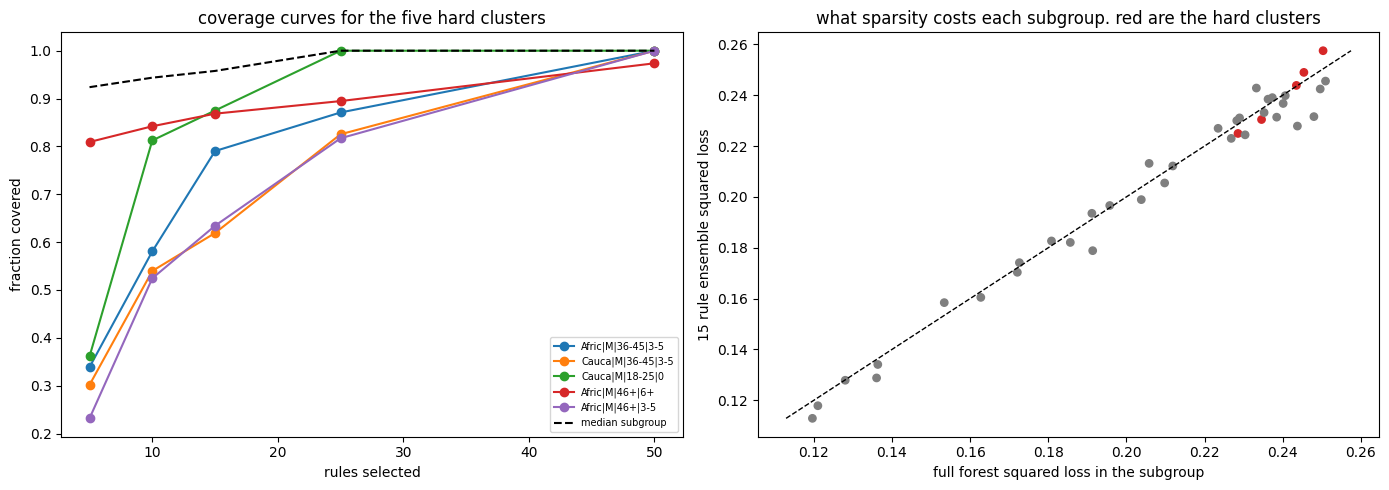

In [27]:
# the coverage picture, one line per hard cluster against the median subgroup
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bud = np.array(budgets)
for g in HARD:
    m = (gran == g).values
    axes[0].plot(bud, [cov_real[b][m].mean() for b in budgets], "o-", label=g)
med = [np.median([cov_real[b][(gran == g).values].mean() for g in SUBGROUPS]) for b in budgets]
axes[0].plot(bud, med, "k--", label="median subgroup")
axes[0].set_xlabel("rules selected")
axes[0].set_ylabel("fraction covered")
axes[0].set_title("coverage curves for the five hard clusters")
axes[0].legend(fontsize=7)

# subgroup squared loss of the 15 rule ensemble against the full forest
gl, sl, nn = [], [], []
for g in SUBGROUPS:
    m = (gran == g).values
    gl.append(np.mean((y_real[m] - y_real.mean() - predfull_real[m]) ** 2))
    sl.append(np.mean((y_real[m] - y_real.mean() - pred15_real[m]) ** 2))
    nn.append(g in HARD)
axes[1].scatter(gl, sl, c=["tab:red" if h else "tab:gray" for h in nn], s=28)
lims = [min(gl + sl), max(gl + sl)]
axes[1].plot(lims, lims, "k--", lw=1)
axes[1].set_xlabel("full forest squared loss in the subgroup")
axes[1].set_ylabel("15 rule ensemble squared loss")
axes[1].set_title("what sparsity costs each subgroup. red are the hard clusters")
plt.tight_layout()
plt.savefig("fig_fire_coverage.png", dpi=200, bbox_inches="tight")
plt.show()

In [21]:
# refit the path on everyone and take the point closest to the readable budget
path_full = fire_path(M, y_c, TREE_SLICES)
ok = [p for p in path_full if 0 < p["n_rules"] <= 15]
point = ok[-1] if ok else path_full[-1]
w_show = point["w"]
sel = np.where(w_show != 0)[0]
print(f"{len(sel)} rules selected at lambda {point['lam_s']:.3f}")

# map every column back to its tree and leaf node
col_tree, col_leaf = np.zeros(R, int), np.zeros(R, int)
for t, s in enumerate(TREE_SLICES):
    leaves = np.where(forest.estimators_[t].tree_.children_left == -1)[0]
    col_tree[s] = t
    col_leaf[s] = leaves

def leaf_conditions(tree, leaf):
    # walk up from the leaf collecting the condition on every edge, then condense per feature
    parent, side = {}, {}
    for node in range(tree.node_count):
        for ch, sd in ((tree.children_left[node], "le"), (tree.children_right[node], "gt")):
            if ch != -1:
                parent[ch], side[ch] = node, sd
    lo, hi = {}, {}
    node = leaf
    while node in parent:
        p = parent[node]
        f, thr = FEATURES[tree.feature[p]], tree.threshold[p]
        if side[node] == "le":
            hi[f] = min(hi.get(f, np.inf), thr)
        else:
            lo[f] = max(lo.get(f, -np.inf), thr)
        node = p
    conds = []
    for f in FEATURES:
        if f in lo and f in hi:
            conds.append(f"{lo[f]:.1f} < {f} <= {hi[f]:.1f}")
        elif f in lo:
            conds.append(f"{f} > {lo[f]:.1f}")
        elif f in hi:
            conds.append(f"{f} <= {hi[f]:.1f}")
    return conds

print()
print("the rule set, grouped by tree, weight is the rule's contribution to the prediction")
for t in sorted(set(col_tree[sel])):
    print(f"tree {t}")
    for j in sel[col_tree[sel] == t]:
        conds = leaf_conditions(forest.estimators_[t].tree_, col_leaf[j])
        cover = int((np.asarray(M[:, j].todense()).ravel() != 0).sum())
        print(f"  weight {w_show[j]:+.3f}  covers {cover:4d} people  " + " and ".join(conds))

12 rules selected at lambda 5.018

the rule set, grouped by tree, weight is the rule's contribution to the prediction
tree 51
  weight +0.254  covers 1496 people  age > 34.5 and priors_count <= 2.5
tree 106
  weight +0.286  covers 2169 people  age > 23.5 and priors_count <= 1.5 and len_of_stay <= 11.5
tree 145
  weight +0.179  covers  710 people  age <= 36.5 and priors_count > 2.5 and len_of_stay > 1.5
tree 150
  weight +0.318  covers 1597 people  age <= 33.5 and priors_count > 1.5 and days_b_screening_arrest > -22.5
tree 159
  weight +0.267  covers  697 people  priors_count > 8.5 and days_b_screening_arrest > -23.5
tree 167
  weight +0.230  covers 1014 people  age <= 31.5 and priors_count > 2.5 and days_b_screening_arrest > -15.5
tree 219
  weight +0.479  covers  173 people  age <= 20.5 and priors_count <= 2.5
tree 247
  weight +0.449  covers 1168 people  priors_count > 5.5 and days_b_screening_arrest > -12.5
tree 419
  weight +0.317  covers  916 people  age <= 27.5 and 0.5 < priors_c

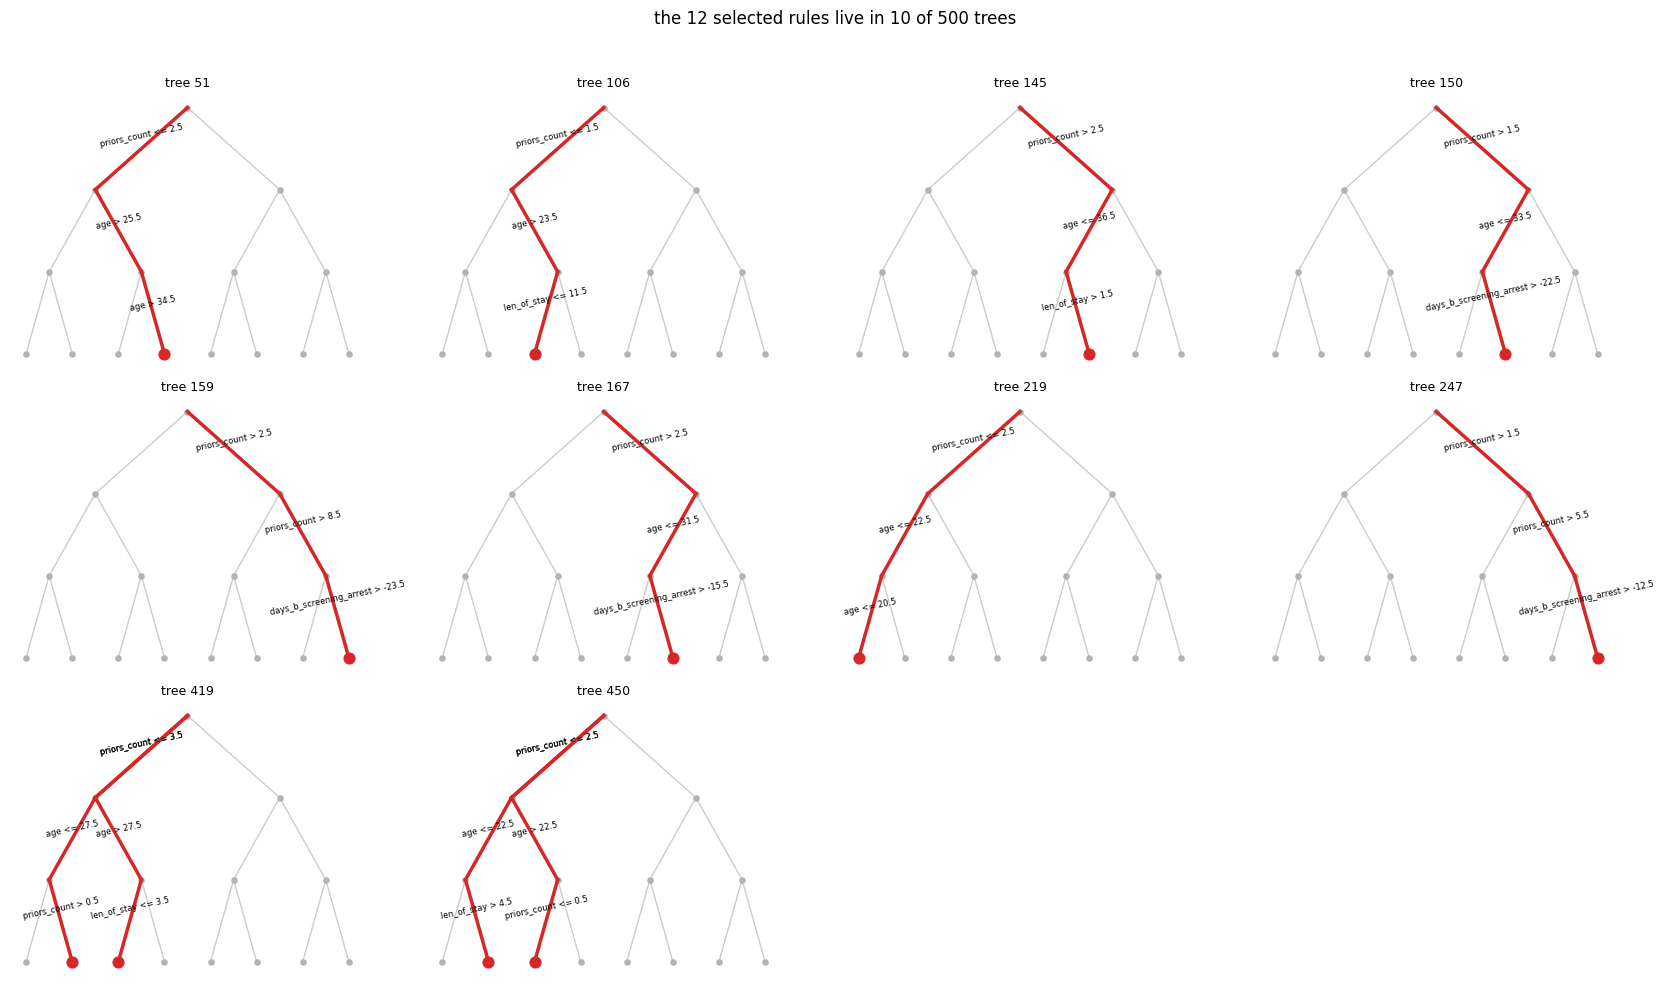

In [26]:
# the paper's figure, each contributing tree with its selected paths highlighted
def draw_tree(ax, tree, chosen_leaves, weights):
    leaves = np.where(tree.children_left == -1)[0]
    xpos = {}
    for k, l in enumerate(leaves):
        xpos[l] = k
    def fill_x(node):
        if node in xpos:
            return xpos[node]
        xpos[node] = 0.5 * (fill_x(tree.children_left[node]) + fill_x(tree.children_right[node]))
        return xpos[node]
    fill_x(0)
    depth = {0: 0}
    order = [0]
    while order:
        n = order.pop()
        for ch in (tree.children_left[n], tree.children_right[n]):
            if ch != -1:
                depth[ch] = depth[n] + 1
                order.append(ch)
    # grey skeleton first
    for n in depth:
        for ch in (tree.children_left[n], tree.children_right[n]):
            if ch != -1:
                ax.plot([xpos[n], xpos[ch]], [-depth[n], -depth[ch]], c="0.8", lw=1, zorder=1)
    ax.scatter([xpos[n] for n in depth], [-depth[n] for n in depth], s=14, c="0.7", zorder=2)
    # highlighted paths for the selected leaves
    parent = {}
    for n in depth:
        for ch in (tree.children_left[n], tree.children_right[n]):
            if ch != -1:
                parent[ch] = n
    for leaf, wgt in zip(chosen_leaves, weights):
        node, col = leaf, ("tab:red" if wgt > 0 else "tab:blue")
        while node in parent:
            p = parent[node]
            ax.plot([xpos[p], xpos[node]], [-depth[p], -depth[node]], c=col, lw=2.5, zorder=3)
            f = FEATURES[tree.feature[p]]
            lab = f"{f} <= {tree.threshold[p]:.1f}" if node == tree.children_left[p] \
                else f"{f} > {tree.threshold[p]:.1f}"
            ax.annotate(lab, (0.5 * (xpos[p] + xpos[node]), -0.5 * (depth[p] + depth[node])),
                        fontsize=6, ha="center", va="bottom", rotation=12)
            node = p
        ax.scatter([xpos[leaf]], [-depth[leaf]], s=60, c=col, zorder=4)
        ax.annotate(f"{wgt:+.2f}", (xpos[leaf], -depth[leaf] - 0.28),
                    fontsize=7, ha="center", color=col)
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

trees_used = sorted(set(col_tree[sel]))
ncol = min(len(trees_used), 4)
nrow = int(np.ceil(len(trees_used) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.2 * nrow), squeeze=False)
for ax in axes.ravel():
    ax.axis("off")
for k, t in enumerate(trees_used):
    ax = axes[k // ncol][k % ncol]
    ax.axis("on")
    mask = col_tree[sel] == t
    draw_tree(ax, forest.estimators_[t].tree_, col_leaf[sel[mask]], w_show[sel[mask]])
    ax.set_title(f"tree {t}", fontsize=9)
plt.suptitle(f"the {len(sel)} selected rules live in {len(trees_used)} of 500 trees"
            , y=1.02)

plt.savefig("fig_fire_rules.png", dpi=200, bbox_inches="tight")
plt.tight_layout()
plt.show()

## Part 4. Is hard to cover heterogeneity or geometry

The null runs
the identical protocol on synthetic A, where the labels contain one rule and nothing else. If the
same subgroups come out hardest to cover there, then hard to cover is a statement about where
people sit in feature space, sparse regions get few dedicated leaves, and not a statement about
heterogeneity.

In [28]:
yA = make_synthetic("A", np.random.default_rng(900)).astype(float)
cov_A, _, _, _ = coverage_run(yA)
ordA = pd.Series({g: cov_A[15][(gran == g).values].mean() for g in SUBGROUPS})
ordR = pd.Series({g: cov_real[15][(gran == g).values].mean() for g in SUBGROUPS})
rho = ordR.rank().corr(ordA.rank(), method="spearman")
print(f"rank correlation of subgroup coverage, real against synthetic A, {rho:.2f}")
hardest_A = ordA.sort_values().head(5).index
hardest_R = ordR.sort_values().head(5).index
print(f"overlap of the five hardest to cover subgroups, real against A, "
      f"{len(set(hardest_A) & set(hardest_R))} of 5")

rank correlation of subgroup coverage, real against synthetic A, 0.83
overlap of the five hardest to cover subgroups, real against A, 5 of 5
